In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

In [2]:
li=pd.read_csv(r"C:\Users\viyya\Downloads\StudentsPerformance.csv")

In [3]:
li.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [16]:
li.isnull().sum()

gender              0
race_ethnicity      0
parent_education    0
lunch               0
test_preparation    0
math score          0
reading score       0
writing score       0
dtype: int64

In [5]:
li.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
li.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
li.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [8]:
li.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [9]:
li=li.rename(columns={'race/ethnicity':'race_ethnicity','parental level of education':'parent_education','test preparation course':'test_preparation'})

In [10]:
li.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   gender            1000 non-null   object
 1   race_ethnicity    1000 non-null   object
 2   parent_education  1000 non-null   object
 3   lunch             1000 non-null   object
 4   test_preparation  1000 non-null   object
 5   math score        1000 non-null   int64 
 6   reading score     1000 non-null   int64 
 7   writing score     1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


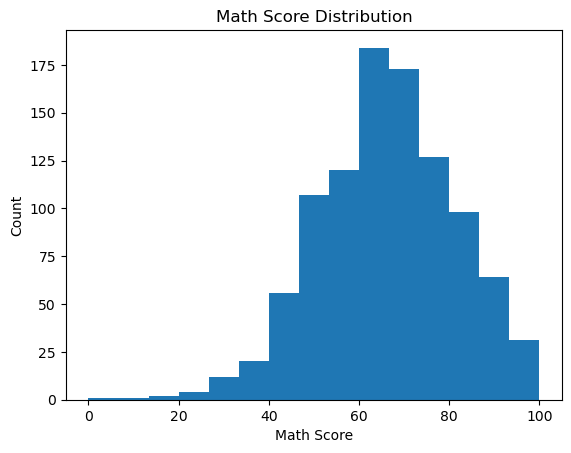

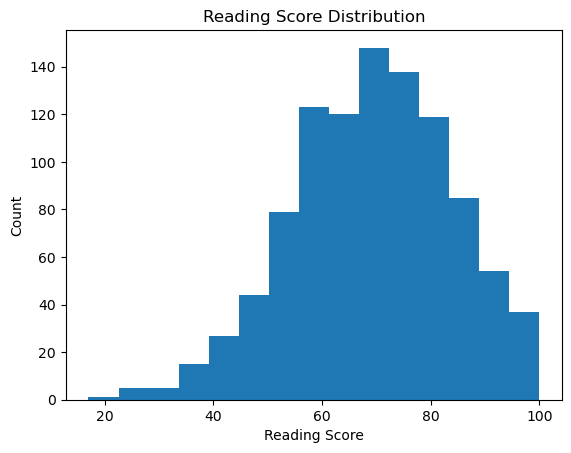

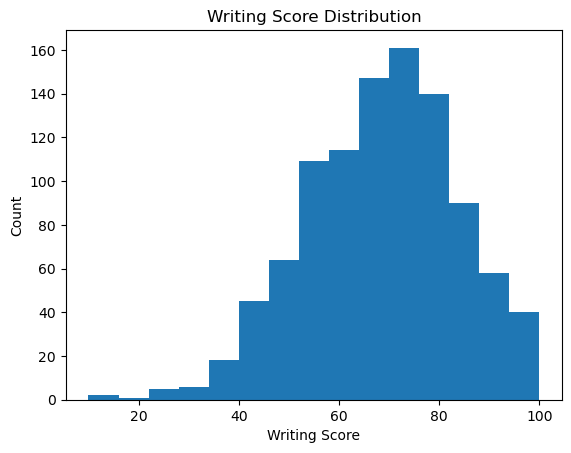

In [11]:
plt.hist(li['math score'], bins=15)
plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Count")
plt.show()

plt.hist(li['reading score'], bins=15)
plt.title("Reading Score Distribution")
plt.xlabel("Reading Score")
plt.ylabel("Count")
plt.show()

plt.hist(li['writing score'], bins=15)
plt.title("Writing Score Distribution")
plt.xlabel("Writing Score")
plt.ylabel("Count")
plt.show()


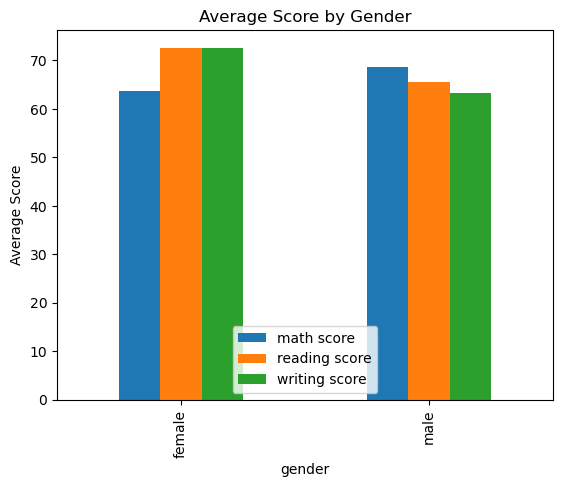

In [12]:
li.groupby('gender')[['math score','reading score','writing score']].mean().plot(kind='bar')
plt.title("Average Score by Gender")
plt.ylabel("Average Score")
plt.show()


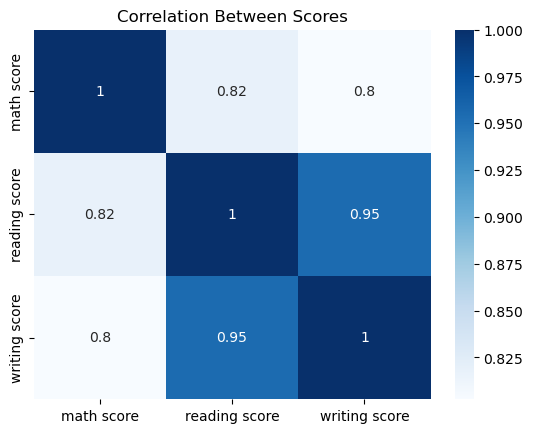

In [13]:
corr = li[['math score','reading score','writing score']].corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Correlation Between Scores")
plt.show()


In [18]:
# prepare features (X) and target (y)
# We will predict "math score" using other columns.
# "li_encoded" is the one-hot encoded version of the original dataframe.

# Drop only the target column from X
X = li_encoded.drop(['math score'], axis=1)
y = li_encoded['math score']

# train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)

# evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
for name, model in [('Linear Regression', lr), ('Random Forest', rf)]:
    y_pred = model.predict(X_test)
    print(name)
    print('MAE:', mean_absolute_error(y_test, y_pred))
    print('MSE:', mean_squared_error(y_test, y_pred))
    print('R2:', r2_score(y_test, y_pred))
    print('---')


Linear Regression
MAE: 4.214763142474851
MSE: 29.095169866715494
R2: 0.8804332983749564
---
Random Forest
MAE: 4.7406428571428565
MSE: 36.69565650921202
R2: 0.8491990721184489
---


In [ ]:
''Final Conclusion:
The Linear Regression model performed the best for predicting math scores,
achieving an R² of 0.88 and an average error of about 4 marks.
Random Forest also performed well but slightly lower with an R² of 0.85. Overall,
the project shows that simple linear relationships were strong enough to accurately predict student performance.''